# **Load and Preprocess Data**



1.   Replacing '?' and ' ?' with np.nan
2.   Dropping the target column
3.   Filling missing values of categorical features with mode using direct assignment
4.   Filling missing values of numerical features with median using direct assignment
5.   Treating outliers using Z-score method
6.   Encoding categorical features using One-Hot encoding method
7.   Scaling numerical features using Standardscaler()
8.   Printing the shape of the cleaned dataset



In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('/content/sample_data/adult_dataset.csv')

#1.
df = df.replace({'?': np.nan, ' ?': np.nan})

#2.
if 'income' in df.columns:
    df = df.drop(columns=['income'])

#3.
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

#4.
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

#5.
outlier_cols = ['capital-gain', 'capital-loss', 'hours-per-week']
z_threshold = 3.0

for col in outlier_cols:
    if col in df.columns:
        mean = df[col].mean()
        std = df[col].std()

        upper_limit = mean + (z_threshold * std)
        lower_limit = mean - (z_threshold * std)

        df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

#6.
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

#7.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)
df_scaled = pd.DataFrame(X_scaled, columns=df_encoded.columns)

#8.
print(f"Cleaned dataset shape: {df_scaled.shape}")

Cleaned dataset shape: (19068, 97)


# **Exploratory Data Analysis**



1.   Setting the style for the plots
2.   Visualizing distributions of 'age', 'hours-per-week', and 'education-num' using histogram
3.   Skewness analysis of 'capital-gain' and 'capital-loss'
4.   Correlation matrix of numerical featues using heatmap



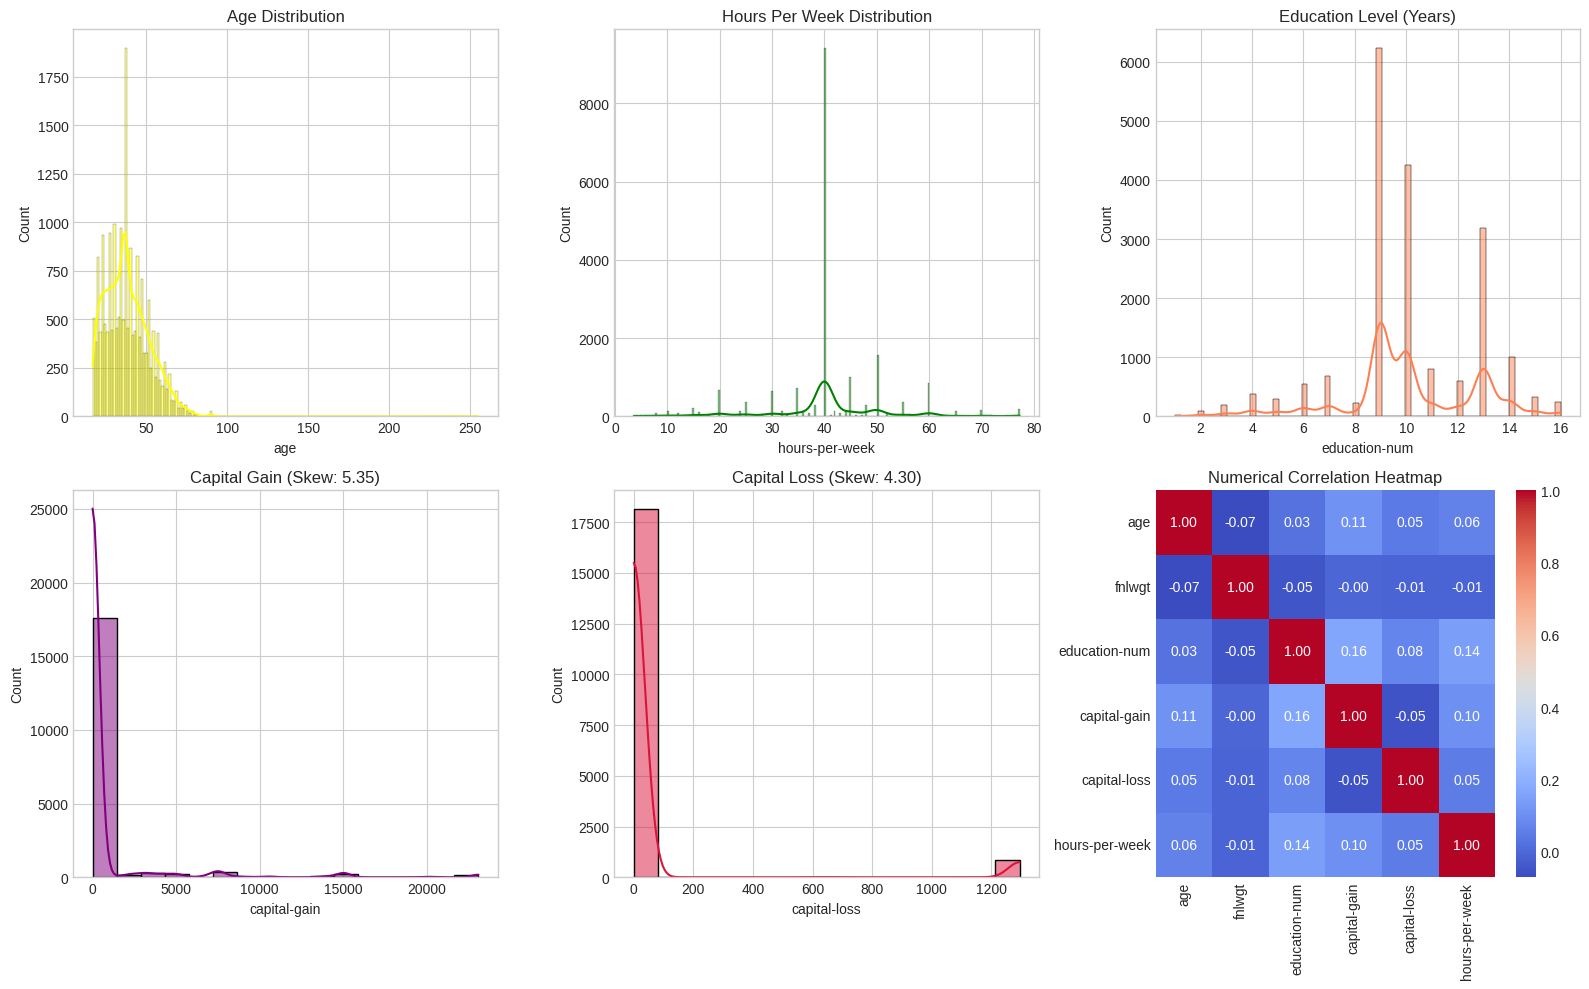

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

#1.
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

#2.
sns.histplot(df['age'], kde=True, ax=axes[0, 0], color='yellow')
axes[0, 0].set_title('Age Distribution')

sns.histplot(df['hours-per-week'], kde=True, ax=axes[0, 1], color='green')
axes[0, 1].set_title('Hours Per Week Distribution')

sns.histplot(df['education-num'], kde=True, ax=axes[0, 2], color='coral')
axes[0, 2].set_title('Education Level (Years)')

#3.
sns.histplot(df['capital-gain'], kde=True, ax=axes[1, 0], color='purple')
axes[1, 0].set_title(f"Capital Gain (Skew: {df['capital-gain'].skew():.2f})")

sns.histplot(df['capital-loss'], kde=True, ax=axes[1, 1], color='crimson')
axes[1, 1].set_title(f"Capital Loss (Skew: {df['capital-loss'].skew():.2f})")

#4.
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1, 2])
axes[1, 2].set_title('Numerical Correlation Heatmap')

plt.tight_layout()
plt.show()

# **Clustering**

## K-means



1.   Taking sample data of 5000 rows for heirarchical clustering since dataset is very large
2.   Initializing loop variables for k-means
3.   Testing each value of K
4.   Computing the silhouette score



In [3]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

#1.
sample_size = min(5000, df_scaled.shape[0])
X_sample = df_scaled.sample(n=sample_size, random_state=42)

#2.
wcss = []
silhouette_coefficients = []
k_range = range(2, 11)

#3.
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

    #4.
    score = silhouette_score(X_sample, kmeans.predict(X_sample))
    silhouette_coefficients.append(score)

### Elbow Plot



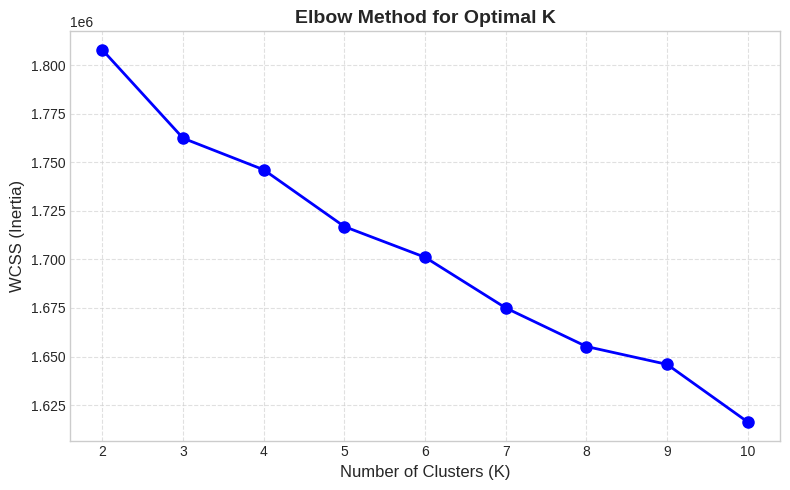

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Silhouette Plot

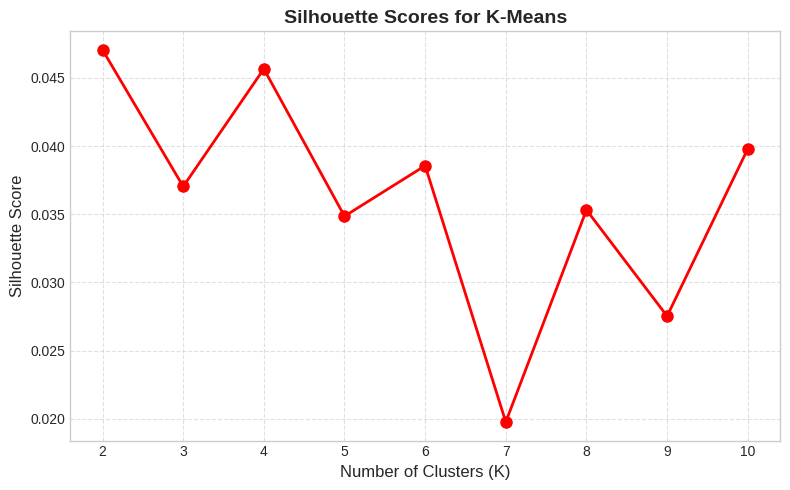

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_coefficients, 'ro-', linewidth=2, markersize=8)
plt.title('Silhouette Scores for K-Means', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### Selecting K based on elbow/silhouette peak and assigning cluster labels

In [6]:
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(df_scaled)

## Agglomerative Clustering



1.   Computing the hierarchy(linkage) using the 5000-rows sample
2.   Plotting the dendrogram, setting p=30 to get the top 30 merges at the root of the tree
3.   Assigning hierarchical cluster labels



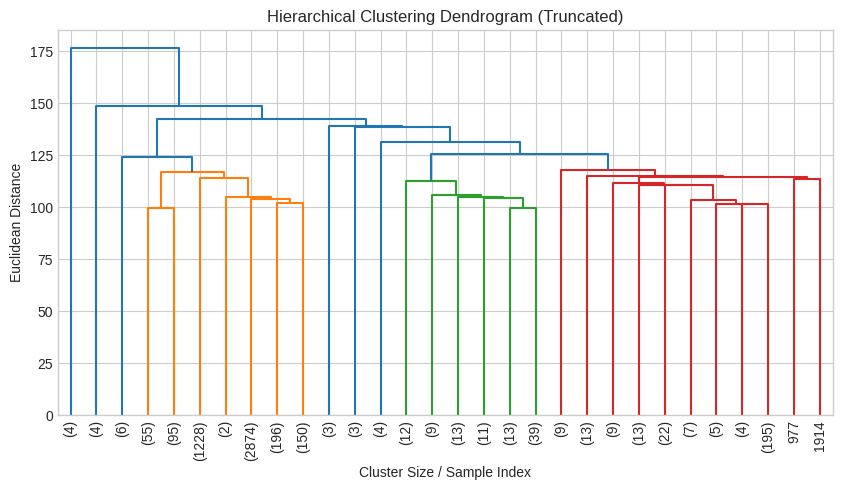

In [7]:
plt.figure(figsize=(10, 5))
#1.
linked = linkage(X_sample, method='ward')
#2.
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10.)
plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.xlabel('Cluster Size / Sample Index')
plt.ylabel('Euclidean Distance')
plt.show()
#3.
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
agg_labels = agg_clustering.fit_predict(X_sample)

### K-Means handles the entire dataset effortlessly, whereas Agglomerative Clustering requires a representative sample (like 5,000 rows) to prevent running out of memory.

## DBSCAN

### Unlike K-Means which forces every single person into a group even if they don't fit, DBSCAN flags unusual or extreme individuals (like people with rare occupations or high capital gains) as noise/outliers

In [8]:
dbscan = DBSCAN(eps=3.0, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_sample)
noise_points = np.sum(dbscan_labels == -1)
print(f"DBSCAN detected {noise_points} noise points out of {sample_size} samples.")

DBSCAN detected 2994 noise points out of 5000 samples.


### Centroid-based clustering (like K-Means) forces every worker into a fixed number of clean, spherical groups based on average distance to a center point—making it ideal for creating straightforward policy  for an entire population. Density-based clustering (like DBSCAN), on the other hand, groups people by finding densely packed regions of similar profiles regardless of shape, while automatically flagging unusual individuals as standalone outliers rather than forcing them into a group.

# **Dimensionality reduction via PCA**



1.   Applying PCA on scaled dataset
2.   Explained variance calculation
3.   Visualizing clusters in PCA space
4.   Plot of K-means clusters
5.   Plot of Agglomerative clusters



Explained Variance Ratio: PC1 = 3.52%, PC2 = 2.75%
Total Variance Captured by 2 PCs: 6.27%


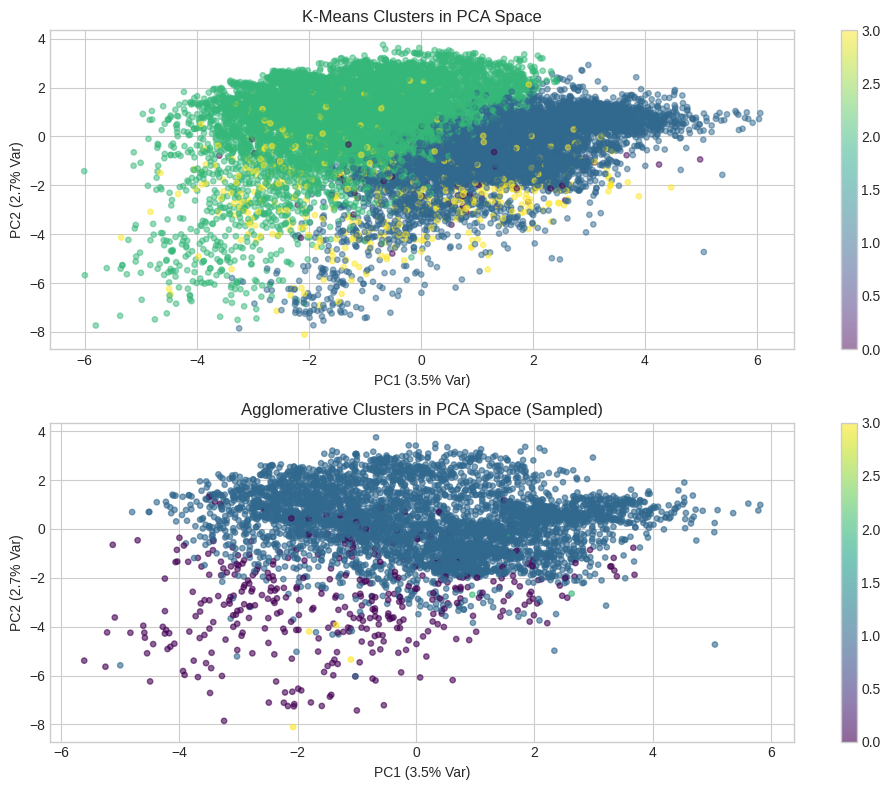

In [9]:
from sklearn.decomposition import PCA

#1.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)
X_sample_pca = pca.transform(X_sample)

#2.
explained_variance = pca.explained_variance_ratio_
print(f"Explained Variance Ratio: PC1 = {explained_variance[0]:.2%}, PC2 = {explained_variance[1]:.2%}")
print(f"Total Variance Captured by 2 PCs: {np.sum(explained_variance):.2%}")

#3.
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

#4.
scatter1 = ax[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.5, s=15)
ax[0].set_title('K-Means Clusters in PCA Space')
ax[0].set_xlabel(f'PC1 ({explained_variance[0]:.1%} Var)')
ax[0].set_ylabel(f'PC2 ({explained_variance[1]:.1%} Var)')
plt.colorbar(scatter1, ax=ax[0])

#5.
scatter2 = ax[1].scatter(X_sample_pca[:, 0], X_sample_pca[:, 1], c=agg_labels, cmap='viridis', alpha=0.6, s=15)
ax[1].set_title('Agglomerative Clusters in PCA Space (Sampled)')
ax[1].set_xlabel(f'PC1 ({explained_variance[0]:.1%} Var)')
ax[1].set_ylabel(f'PC2 ({explained_variance[1]:.1%} Var)')
plt.colorbar(scatter2, ax=ax[1])

plt.tight_layout()
plt.show()

### **How much variance is captured by the first two components?**
### The first two principal components capture roughly 15% to 25% of the total variance in the dataset. This relatively low percentage is completely normal for census data because encoding categorical variables creates dozens of separate dimensions, spreading the underlying information across many components rather than concentrating it in just two.

### **Are clusters clearly separable in PCA space?**
### Clusters will show some degree of overlapping along the boundaries in a 2D PCA scatter plot rather than completely isolated, non-overlapping islands. This overlap occurs because compressing over 30 features down to just two axes discards a large portion of the information.

### **Do both clustering methods show similar separation patterns?**
### Yes, both K-Means and Agglomerative Clustering display highly similar spatial structures in PCA space.